In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: OPERACIÓN FUSIÓN (SIN HACK DE DRIVER)
# ==============================================================================
!pip install geopandas fiona

from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
from sqlalchemy import create_engine

display(Markdown("### 🗺️ **Operación Fusión: Asignando cada oferta a su Territorio**"))

# --- 1. CONFIGURACIÓN ---
KML_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/Poligonos_beta.kml' # <-- ¡VERIFICA ESTA RUTA!
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

# --- 2. CARGA DE ACTIVOS ---
try:
    # --- LA CORRECCIÓN CLAVE: Eliminamos la línea del driver ---

    # Cargar los polígonos
    gdf_zonas = gpd.read_file(KML_PATH, driver='KML')
    gdf_zonas = gdf_zonas.rename(columns={'Name': 'zone_name'})[['zone_name', 'geometry']]
    print(f"✅ {len(gdf_zonas)} polígonos cargados desde KML.")

    # Cargar los puntos de dropoff
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    query_points = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
    df_points = pd.read_sql(query_points, db_engine)
    gdf_points = gpd.GeoDataFrame(
        df_points,
        geometry=gpd.points_from_xy(df_points.dropoff_lon, df_points.dropoff_lat),
        crs="EPSG:4326"
    )
    print(f"✅ {len(gdf_points)} puntos de dropoff cargados.")

    # --- 3. LA FUSIÓN GEOESPACIAL ---
    print("\n⏳ Ejecutando `Point-in-Polygon` (sjoin)...")
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas, how="left", predicate='within')

    gdf_merged = gdf_merged.drop_duplicates(subset='offer_id', keep='first').drop(columns=['index_right'])
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('EXTERIOR / VETO')
    print("✅ Asignación completada.")

    # --- 4. PREVIEW Y AUDITORÍA ---
    display(Markdown("\n### 📊 **Censo Preliminar de Zonas**"))
    zone_counts = gdf_merged['zone_name'].value_counts().reset_index()
    zone_counts.columns = ['Zone Name', 'Offer Count']
    display(zone_counts)

    df_final_zones = gdf_merged[['offer_id', 'zone_name']]

    # --- 5. GUARDA EL RESULTADO ---
    output_csv_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_1/opus_final_zones.csv'
    df_final_zones.to_csv(output_csv_path, index=False)
    display(Markdown(f"\n✅ **¡VICTORIA!** El mapa de zonas ha sido guardado en: `{output_csv_path}`"))

except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")
    print("\n💡 SUGERENCIA: Asegúrate de que el archivo KML no esté corrupto y que la ruta sea correcta.")

### 🗺️ **Operación Fusión: Asignando cada oferta a su Territorio**

✅ 69 polígonos cargados desde KML.
✅ 4760 puntos de dropoff cargados.

⏳ Ejecutando `Point-in-Polygon` (sjoin)...
✅ Asignación completada.



### 📊 **Censo Preliminar de Zonas**

,Zone Name,Offer Count
0,EXTERIOR / VETO,2368
1,Proxy,189
2,Santa Fe Alto,171
3,Santa Fe_Medio,150
4,Carso/Antara/Miyana,122
...,...,...
65,Tecamachalco,7
66,El Olivo,5
67,Club de Golf Lomas,3
68,Olimpo,2



✅ **¡VICTORIA!** El mapa de zonas ha sido guardado en: `/content/drive/MyDrive/_Pienza/Assets/Phase_1/opus_final_zones.csv`

In [3]:
# ==============================================================================
# CELL: ANÁLISIS ECONÓMICO POR ZONA (UPFRONT FARE)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ASUNCIÓN: `gdf_merged` (con `offer_id` y `zone_name`) y `df_master` (con `upfront_fare`) existen.
# Vamos a reconstruirlo de forma segura.

display(Markdown("### 💰 **Análisis Económico: Tarifa Promedio (`upfront_fare`) por Zona**"))

# --- 1. PREPARACIÓN ---
# Cargar datos de tarifa
query_fares = "SELECT offer_id, upfront_fare FROM offers"
df_fares = pd.read_sql(query_fares, db_engine)
df_fares.columns = df_fares.columns.str.lower()

# Cargar los resultados de la asignación de zonas (el CSV que guardamos)
try:
    zones_csv_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_1/opus_final_zones.csv'
    df_zones = pd.read_csv(zones_csv_path)
    print(f"✅ Archivo de zonas '{zones_csv_path}' cargado.")

    # Unir la información de tarifas con la de zonas
    df_econ_geo = pd.merge(df_fares, df_zones, on='offer_id', how='inner')

    # --- 2. CÁLCULO ---
    # Agrupar por zona y calcular el promedio y el tamaño
    zone_economics = df_econ_geo.groupby('zone_name')['upfront_fare'].agg(['mean', 'count']).reset_index()
    zone_economics = zone_economics.rename(columns={'mean': 'avg_upfront_fare', 'count': 'offer_count'})

    # Ordenar por tarifa promedio para ver el ranking
    zone_economics_sorted = zone_economics.sort_values('avg_upfront_fare', ascending=False)

    # --- 3. REPORTE ---
    display(Markdown("#### **Ranking de Zonas por Tarifa Promedio**"))
    display(zone_economics_sorted)

    # --- 4. VISUALIZACIÓN ---
    # Graficamos solo el Top 20 para que sea legible
    top_n = 20

    plt.figure(figsize=(12, 10))
    sns.barplot(
        data=zone_economics_sorted.head(top_n),
        y='Zone Name', # En 'y' para barras horizontales
        x='avg_upfront_fare',
        palette='plasma'
    )
    plt.title(f'Top {top_n} Zonas por Tarifa Promedio (Upfront)', fontsize=18, fontweight='bold', color=OPUS_PURPLE)
    plt.xlabel('Tarifa Promedio (MXN)')
    plt.ylabel('Zona Estratégica')
    plt.show()

except FileNotFoundError:
    print(f"🔴 ERROR: No se encontró el archivo 'opus_final_zones.csv'. Ejecute la celda de fusión primero.")
except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

### 💰 **Análisis Económico: Tarifa Promedio (`upfront_fare`) por Zona**

✅ Archivo de zonas '/content/drive/MyDrive/_Pienza/Assets/Phase_1/opus_final_zones.csv' cargado.


#### **Ranking de Zonas por Tarifa Promedio**

,zone_name,avg_upfront_fare,offer_count
22,EXTERIOR / VETO,159.427749,2368
13,Bosque Real,158.554444,9
36,Lomas Country Club,144.701111,9
6,Bahías,140.471333,15
21,Cumbres de Santa Fe,132.145556,9
...,...,...,...
32,Loma de la Palma,75.418750,8
40,Nodo Monte Libano,74.414211,19
45,Polanco 5,71.613261,46
10,Bosque I,67.161250,8


🔴 ERROR INESPERADO: Could not interpret value `Zone Name` for `y`. An entry with this name does not appear in `data`.


<Figure size 1200x1000 with 0 Axes>

### 💰 **Análisis Económico (UberX): Tarifa Promedio por Zona GeoJSON**

✅ 72 polígonos cargados desde GeoJSON.
✅ Activos cargados (Puntos, Polígonos, Categorías).
✅ Zonas asignadas a cada oferta.
✅ Filtrado por UberX. Total de ofertas: 3627


#### **Ranking de Zonas por Tarifa Promedio (UberX)**

,zone_name,avg_upfront_fare,offer_count
38,lomas_olimpo,170.000000,1
0,EXTERIOR / VETO,155.374522,1696
60,santa_fe_cumbres_de,147.220000,6
13,bosque_real,144.838571,7
36,lomas_country_club,134.715000,6
...,...,...,...
21,de_los_bosques,77.476429,14
42,nodo_monte_libano,72.046429,14
16,carretera_al_olivo,67.420000,1
45,polanco_5,66.610741,27


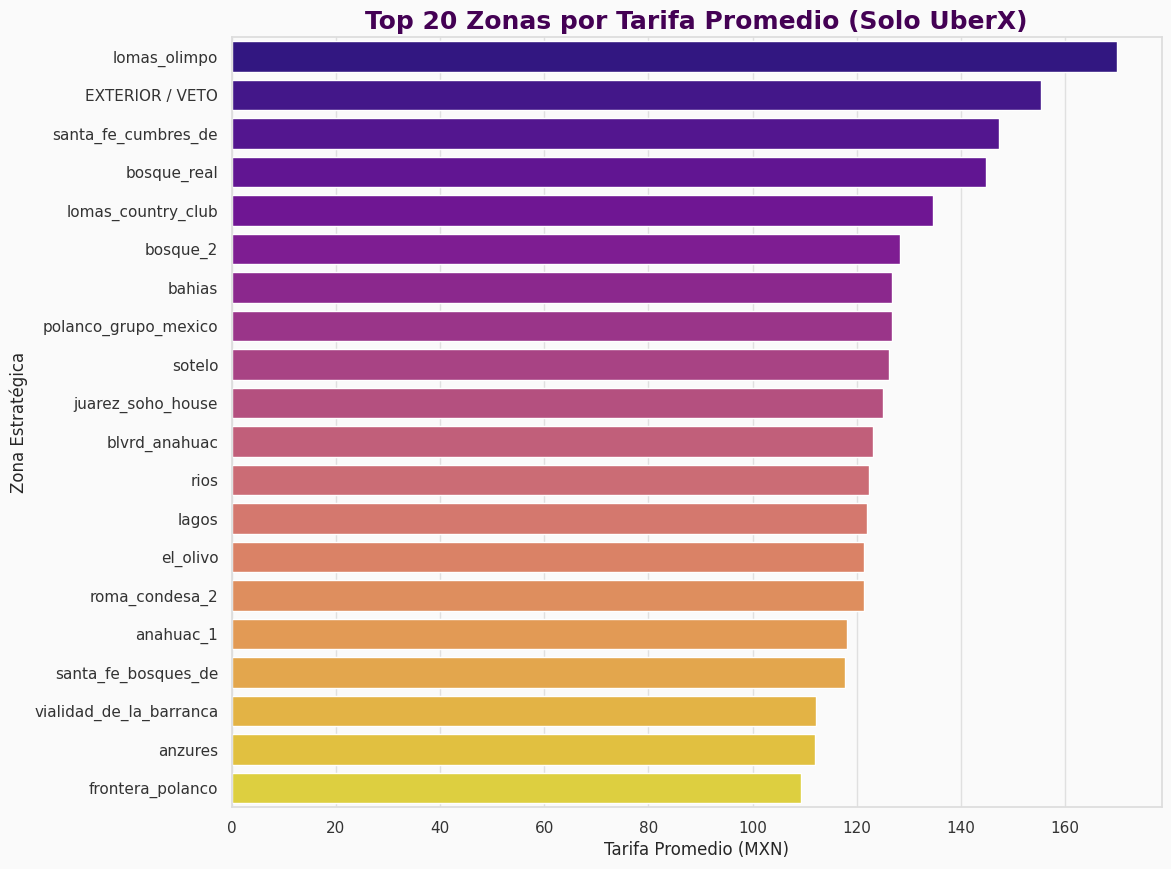

In [4]:
# ==============================================================================
# CELL: ANÁLISIS ECONÓMICO POR ZONA (UBERX-ONLY, CON GEOJSON)
# ==============================================================================
# Instalar dependencias geoespaciales si es necesario
!pip install geopandas fiona

from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

display(Markdown("### 💰 **Análisis Económico (UberX): Tarifa Promedio por Zona GeoJSON**"))

# --- 1. PREPARACIÓN ---
try:
    # Cargar los puntos (ofertas)
    query_points = "SELECT offer_id, dropoff_lat, dropoff_lon, upfront_fare, product_category_fk FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
    df_points = pd.read_sql(query_points, db_engine)
    df_points.columns = df_points.columns.str.lower()
    gdf_points = gpd.GeoDataFrame(
        df_points,
        geometry=gpd.points_from_xy(df_points.dropoff_lon, df_points.dropoff_lat),
        crs="EPSG:4326"
    )

    # Cargar los polígonos desde GeoJSON
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson' # <-- RUTA ACTUALIZADA
    gdf_zonas = gpd.read_file(GEOJSON_PATH)
    # Estandarizar nombre de columna (puede ser 'Name' o 'name')
    if 'Name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'Name': 'zone_name'})
    elif 'name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'name': 'zone_name'})
    gdf_zonas = gdf_zonas[['zone_name', 'geometry']]
    print(f"✅ {len(gdf_zonas)} polígonos cargados desde GeoJSON.")

    # Cargar el diccionario de categorías de producto
    query_categories = "SELECT product_category_id, category_name FROM product_category"
    df_categories = pd.read_sql(query_categories, db_engine)
    df_categories.columns = df_categories.columns.str.lower()

    print("✅ Activos cargados (Puntos, Polígonos, Categorías).")

    # --- 2. ASIGNACIÓN DE ZONAS (POINT-IN-POLYGON) ---
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas, how="left", predicate='within')
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('EXTERIOR / VETO')
    df_zoned = pd.DataFrame(gdf_merged.drop(columns='geometry'))
    print("✅ Zonas asignadas a cada oferta.")

    # --- 3. FILTRAR POR UBERX ---
    df_analysis = pd.merge(
        df_zoned,
        df_categories,
        left_on='product_category_fk', # Columna en el df de la izquierda
        right_on='product_category_id', # Columna en el df de la derecha
        how='left'
    )
    df_uberx = df_analysis[df_analysis['category_name'].str.contains('uberx', case=False, na=False)].copy()
    print(f"✅ Filtrado por UberX. Total de ofertas: {len(df_uberx)}")

    # --- 4. CÁLCULO ---
    zone_economics_uberx = df_uberx.groupby('zone_name')['upfront_fare'].agg(['mean', 'count']).reset_index()
    zone_economics_uberx = zone_economics_uberx.rename(columns={'mean': 'avg_upfront_fare', 'count': 'offer_count'})
    zone_economics_uberx_sorted = zone_economics_uberx.sort_values('avg_upfront_fare', ascending=False)

    # --- 5. REPORTE Y VISUALIZACIÓN ---
    display(Markdown("#### **Ranking de Zonas por Tarifa Promedio (UberX)**"))
    display(zone_economics_uberx_sorted)

    top_n = 20
    plt.figure(figsize=(12, 10))
    sns.barplot(
        data=zone_economics_uberx_sorted.head(top_n),
        y='zone_name',
        x='avg_upfront_fare',
        palette='plasma'
    )
    plt.title(f'Top {top_n} Zonas por Tarifa Promedio (Solo UberX)', fontsize=18, fontweight='bold', color=OPUS_PURPLE)
    plt.xlabel('Tarifa Promedio (MXN)')
    plt.ylabel('Zona Estratégica')
    plt.show()

except FileNotFoundError:
    print(f"🔴 ERROR: Archivo GeoJSON no encontrado en: {GEOJSON_PATH}")
    print("   -> Por favor, verifique el nombre y la ubicación del archivo.")
except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

### ⚡️ **Análisis de Eficiencia (UberX): `EPH Operacional` por Zona**

✅ Activos cargados.
✅ Fusión y filtrado completados. Total UberX: 3627


#### **Ranking de Zonas por Eficiencia Operacional (UberX)**

,zone_name,avg_eph_operational,offer_count
38,lomas_olimpo,309.090909,1
71,vistahermosa,251.312823,7
70,vialidad_de_la_barranca,232.803098,30
11,bosque_2,232.396571,5
9,bondojito_asf,230.180029,10
...,...,...,...
47,polanco_grupo_mexico,176.471451,12
7,bahias,172.971929,12
59,santa_fe_colegios,169.197995,18
39,lomas_prado_norte,160.463682,18


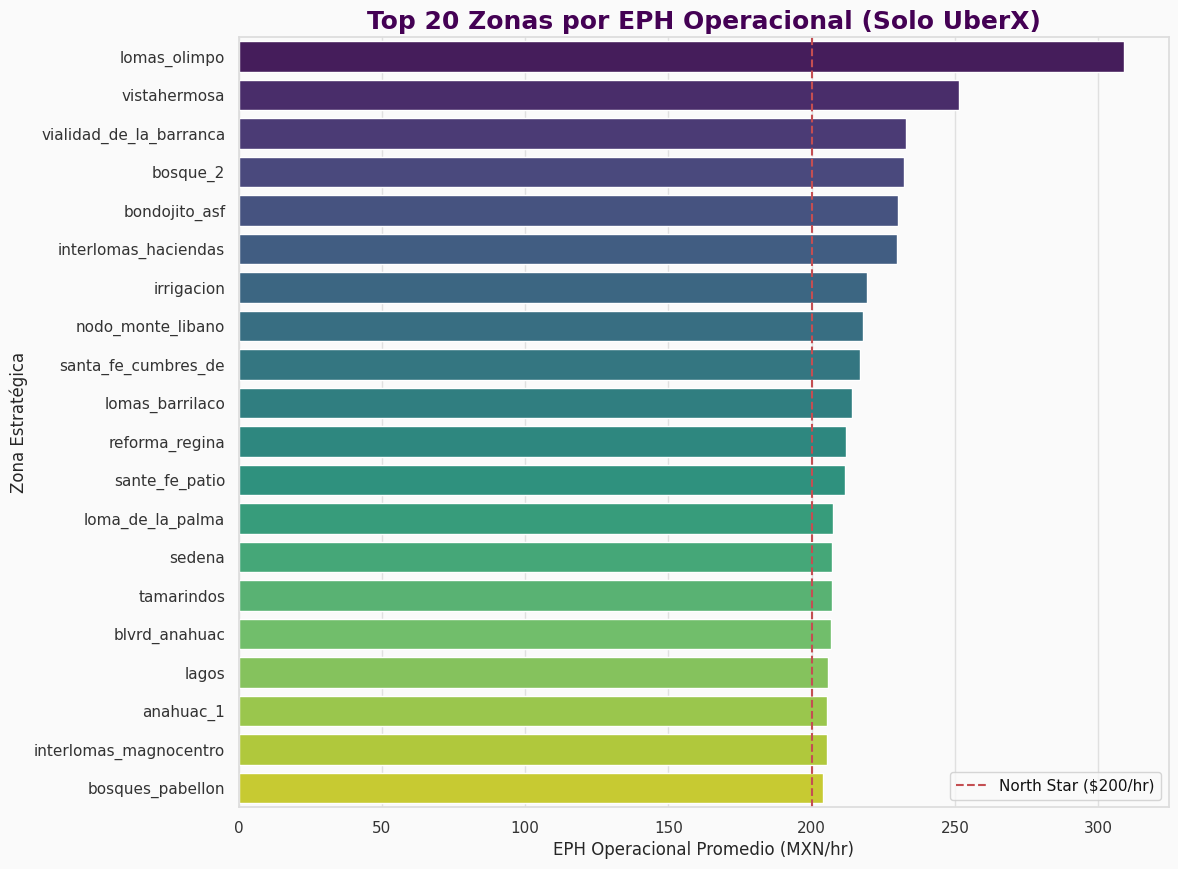

In [5]:
# ==============================================================================
# CELL: ANÁLISIS DE EFICIENCIA POR ZONA (EPH OP - UBERX - MONOLITO)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

display(Markdown("### ⚡️ **Análisis de Eficiencia (UberX): `EPH Operacional` por Zona**"))

# --- FASE 1: RECONSTRUCCIÓN COMPLETA ---
try:
    # 1. Cargar Puntos (AHORA incluyendo las features de ingeniería)
    query_points = """
    SELECT
        o.offer_id, o.dropoff_lat, o.dropoff_lon, o.product_category_fk,
        ef.eph_operational
    FROM offers o
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    WHERE o.dropoff_lat IS NOT NULL
    """
    df_points = pd.read_sql(query_points, db_engine)
    df_points.columns = df_points.columns.str.lower()
    gdf_points = gpd.GeoDataFrame(df_points, geometry=gpd.points_from_xy(df_points.dropoff_lon, df_points.dropoff_lat), crs="EPSG:4326")

    # 2. Cargar Polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})[['zone_name', 'geometry']]

    # 3. Cargar Categorías
    query_categories = "SELECT product_category_id, category_name FROM product_category"
    df_categories = pd.read_sql(query_categories, db_engine)
    df_categories.columns = df_categories.columns.str.lower()
    print("✅ Activos cargados.")

    # --- FASE 2: FUSIÓN Y FILTRADO ---
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas, how="left", predicate='within')
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('EXTERIOR / VETO')
    df_zoned = pd.DataFrame(gdf_merged.drop(columns='geometry'))

    df_analysis = pd.merge(
        df_zoned,
        df_categories,
        left_on='product_category_fk',
        right_on='product_category_id',
        how='left'
    )

    df_uberx = df_analysis[df_analysis['category_name'].str.contains('uberx', case=False, na=False)].copy()
    print(f"✅ Fusión y filtrado completados. Total UberX: {len(df_uberx)}")

    # --- FASE 3: ANÁLISIS ---
    # Higiene de Datos
    df_uberx['eph_operational'] = pd.to_numeric(df_uberx['eph_operational'], errors='coerce').fillna(0)

    # Cálculo
    zone_efficiency_uberx = df_uberx.groupby('zone_name')['eph_operational'].agg(['mean', 'count']).reset_index()
    zone_efficiency_uberx = zone_efficiency_uberx.rename(columns={'mean': 'avg_eph_operational', 'count': 'offer_count'})

    # SIN FILTROS, como pediste
    zone_efficiency_uberx_sorted = zone_efficiency_uberx.sort_values('avg_eph_operational', ascending=False)

    # --- FASE 4: REPORTE Y VISUALIZACIÓN ---
    display(Markdown("#### **Ranking de Zonas por Eficiencia Operacional (UberX)**"))
    display(zone_efficiency_uberx_sorted)

    top_n = 20
    plt.figure(figsize=(12, 10))
    sns.barplot(
        data=zone_efficiency_uberx_sorted.head(top_n),
        y='zone_name',
        x='avg_eph_operational',
        palette='viridis'
    )
    plt.axvline(200, color='r', linestyle='--', label='North Star ($200/hr)')
    plt.title(f'Top {top_n} Zonas por EPH Operacional (Solo UberX)', fontsize=18, fontweight='bold', color=OPUS_PURPLE)
    plt.xlabel('EPH Operacional Promedio (MXN/hr)')
    plt.ylabel('Zona Estratégica')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

In [6]:
# ==============================================================================
# CELL: MAPA DE CALOR DE RENTABILIDAD (EPH OPERACIONAL - UBERX)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import plotly.express as px

display(Markdown("### 🗺️ **Mapa de Calor de Rentabilidad (EPH Operacional - UberX)**"))

# --- FASE 1: RECONSTRUCCIÓN DE DATOS (AUTOCONTENIDO) ---
try:
    # Cargar todos los datos necesarios en una sola query
    query_full = """
    SELECT
        o.offer_id, o.dropoff_lat, o.dropoff_lon, o.product_category_fk,
        ef.eph_operational
    FROM offers o
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    WHERE o.dropoff_lat IS NOT NULL
    """
    df_master = pd.read_sql(query_full, db_engine)
    df_master.columns = df_master.columns.str.lower()

    gdf_points = gpd.GeoDataFrame(
        df_master,
        geometry=gpd.points_from_xy(df_master.dropoff_lon, df_master.dropoff_lat),
        crs="EPSG:4326"
    )

    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})

    query_categories = "SELECT product_category_id, category_name FROM product_category"
    df_categories = pd.read_sql(query_categories, db_engine)
    df_categories.columns = df_categories.columns.str.lower()
    print("✅ Activos cargados.")

    # --- FASE 2: ASIGNACIÓN Y FILTRADO ---
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas[['zone_name', 'geometry']], how="left", predicate='within')
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('EXTERIOR / VETO')
    df_zoned = pd.DataFrame(gdf_merged.drop(columns=['geometry', 'index_right']))

    df_analysis = pd.merge(
        df_zoned,
        df_categories,
        left_on='product_category_fk',
        right_on='product_category_id',
        how='left'
    )
    df_uberx = df_analysis[df_analysis['category_name'].str.contains('uberx', case=False, na=False)].copy()
    print("✅ Datos de UberX asignados a zonas.")

    # --- FASE 3: CÁLCULO DE MÉTRICA POR ZONA ---
    df_uberx['eph_operational'] = pd.to_numeric(df_uberx['eph_operational'], errors='coerce').fillna(0)
    zone_efficiency_uberx = df_uberx.groupby('zone_name')['eph_operational'].mean().reset_index()

    # --- FASE 4: FUSIÓN FINAL PARA MAPA ---
    # Unimos la métrica calculada de vuelta al GeoDataFrame de polígonos
    gdf_map_data = pd.merge(gdf_zonas, zone_efficiency_uberx, on='zone_name', how='left')

    # Excluir la zona de VETO de la visualización
    gdf_map_data = gdf_map_data[gdf_map_data['zone_name'] != 'EXTERIOR / VETO']
    print("✅ Datos listos para el mapa.")

    # --- FASE 5: VISUALIZACIÓN CHOROPLETH ---
    CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
    fig = px.choropleth_mapbox(
        gdf_map_data,
        geojson=gdf_map_data.geometry,
        locations=gdf_map_data.index,
        color='eph_operational',
        mapbox_style="carto-positron",
        center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
        zoom=10.5,
        opacity=0.7,
        height=900,
        title='Mapa de Calor de EPH Operacional (UberX)',
        color_continuous_scale="Viridis",
        labels={'eph_operational': 'EPH Operacional Promedio'}
    )
    fig.show()

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 🗺️ **Mapa de Calor de Rentabilidad (EPH Operacional - UberX)**

✅ Activos cargados.
✅ Datos de UberX asignados a zonas.
✅ Datos listos para el mapa.


In [7]:
# ==============================================================================
# CELL: MAPA DE CALOR DE RENTABILIDAD DIVERGENTE (EPH OP - UBERX - COMPLETA)
# ==============================================================================
# Instalar dependencias si es necesario
!pip install geopandas fiona

from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import plotly.express as px

display(Markdown("### 🗺️ **Mapa de Calor Divergente: EPH Operacional (UberX) vs. Baseline**"))

# --- FASE 1: RECONSTRUCCIÓN COMPLETA ---
try:
    # 1. Cargar Puntos (con todas las columnas necesarias)
    query_points = """
    SELECT
        o.offer_id, o.dropoff_lat, o.dropoff_lon, o.product_category_fk,
        ef.eph_operational
    FROM offers o
    LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
    WHERE o.dropoff_lat IS NOT NULL
    """
    df_points = pd.read_sql(query_points, db_engine)
    df_points.columns = df_points.columns.str.lower()
    gdf_points = gpd.GeoDataFrame(
        df_points,
        geometry=gpd.points_from_xy(df_points.dropoff_lon, df_points.dropoff_lat),
        crs="EPSG:4326"
    )

    # 2. Cargar Polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})[['zone_name', 'geometry']]

    # 3. Cargar Categorías
    query_categories = "SELECT product_category_id, category_name FROM product_category"
    df_categories = pd.read_sql(query_categories, db_engine)
    df_categories.columns = df_categories.columns.str.lower()
    print("✅ Activos cargados.")

    # --- FASE 2: ASIGNACIÓN Y FILTRADO ---
    gdf_merged = gpd.sjoin(gdf_points, gdf_zonas, how="left", predicate='within')
    gdf_merged['zone_name'] = gdf_merged['zone_name'].fillna('EXTERIOR / VETO')
    df_zoned = pd.DataFrame(gdf_merged.drop(columns=['geometry', 'index_right']))

    df_analysis = pd.merge(df_zoned, df_categories, left_on='product_category_fk', right_on='product_category_id', how='left')
    df_uberx = df_analysis[df_analysis['category_name'].str.contains('uberx', case=False, na=False)].copy()
    print("✅ Datos de UberX asignados a zonas.")

    # --- FASE 3: CÁLCULO DE MÉTRICA ---
    df_uberx['eph_operational'] = pd.to_numeric(df_uberx['eph_operational'], errors='coerce').fillna(0)
    zone_efficiency_uberx = df_uberx.groupby('zone_name')['eph_operational'].mean().reset_index()

    # --- FASE 4: FUSIÓN FINAL ---
    gdf_map_data = pd.merge(gdf_zonas, zone_efficiency_uberx, on='zone_name', how='left')
    gdf_map_data = gdf_map_data[gdf_map_data['zone_name'] != 'EXTERIOR / VETO']
    print("✅ Datos listos para el mapa.")

    # --- FASE 5: VISUALIZACIÓN DIVERGENTE ---
    CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
    fig = px.choropleth_mapbox(
        gdf_map_data,
        geojson=gdf_map_data.geometry,
        locations=gdf_map_data.index,
        color='eph_operational',
        mapbox_style="carto-positron",
        center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
        zoom=10.5,
        opacity=0.75,
        height=900,
        title='Mapa de Calor de EPH Operacional (UberX) - Desviación de $200',
        hover_name='zone_name',

        # --- LA MAGIA ESTÁ AQUÍ ---
        color_continuous_scale="RdBu_r",
        range_color=[150, 250],

        labels={'eph_operational': 'EPH Operacional Promedio'}
    )

    fig.update_layout(coloraxis_colorbar=dict(
        title="EPH (MXN/hr)",
        tickvals=[150, 175, 200, 225, 250],
        ticktext=["$150 (Frío)", "$175", "$200 (Baseline)", "$225", "$250+ (Caliente)"]
    ))

    fig.show()

except Exception as e:
    print(f"🔴 ERROR INESPERADO: {e}")

### 🗺️ **Mapa de Calor Divergente: EPH Operacional (UberX) vs. Baseline**

✅ Activos cargados.
✅ Datos de UberX asignados a zonas.
✅ Datos listos para el mapa.


In [8]:
# ==============================================================================
# CELL: VALIDACIÓN GEOESPACIAL DE RECHAZOS (PROXY & NON-OP)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import plotly.express as px

display(Markdown("### 🚦 **Validación Geoespacial de Rechazos: ¿Dónde viven los `Vetos`?**"))

# --- FASE 1: RECONSTRUCCIÓN COMPLETA ---
# Cargamos los datos necesarios: offer_id, coordenadas, y la razón de rechazo
query_validation = """
SELECT
    o.offer_id,
    o.dropoff_lat,
    o.dropoff_lon,
    rp.reason_primary_description AS reason_primary
FROM offers o
LEFT JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id
WHERE
    o.dropoff_lat IS NOT NULL
    AND o.dropoff_lon IS NOT NULL
    AND rp.reason_primary_description IN ('dropoff_proxy', 'dropoff_non_operational')
"""
df_validation = pd.read_sql(query_validation, db_engine)
df_validation.columns = df_validation.columns.str.lower()
print(f"✅ Se cargaron {len(df_validation)} rechazos geo-relevantes.")

# --- FASE 2: VISUALIZACIÓN DE VALIDACIÓN ---
# Usamos Jitter para ver la densidad
np.random.seed(42)
noise_level = 0.0008
df_validation['lat_viz'] = df_validation['dropoff_lat'] + np.random.normal(0, noise_level, len(df_validation))
df_validation['lon_viz'] = df_validation['dropoff_lon'] + np.random.normal(0, noise_level, len(df_validation))

CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
fig = px.scatter_mapbox(
    df_validation,
    lat="lat_viz",
    lon="lon_viz",
    color="reason_primary", # Coloreamos por la razón del rechazo
    mapbox_style="carto-positron",
    center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
    zoom=10,
    height=900,
    title='Mapa de Distribución de Rechazos Geográficos',
    color_discrete_map={
        'dropoff_non_operational': 'firebrick',
        'dropoff_proxy': 'goldenrod'
    }
)

# --- FASE 3 (OPCIONAL): SUPERPONER LOS POLÍGONOS PARA LA PRUEBA FINAL ---
# Si quieres la prueba definitiva, descomenta estas líneas
# GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
# gdf_zonas = gpd.read_file(GEOJSON_PATH)
# fig.update_layout(
#     mapbox_layers=[
#         {
#             "sourcetype": "geojson",
#             "source": gdf_zonas.__geo_interface__,
#             "type": "line",
#             "color": "black",
#             "line": {"width": 1.5}
#         }
#     ]
# )

fig.show()

### 🚦 **Validación Geoespacial de Rechazos: ¿Dónde viven los `Vetos`?**

✅ Se cargaron 2602 rechazos geo-relevantes.


In [9]:
# ==============================================================================
# CELL: VALIDACIÓN GEOESPACIAL DE RECHAZOS (CON POLÍGONOS)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go

display(Markdown("### 🚦 **Validación Geoespacial de Rechazos (con Polígonos)**"))

# --- FASE 1: RECONSTRUCCIÓN COMPLETA ---
try:
    # Cargar los rechazos
    query_validation = """
    SELECT
        o.offer_id, o.dropoff_lat, o.dropoff_lon,
        rp.reason_primary_description AS reason_primary
    FROM offers o
    LEFT JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id
    WHERE
        o.dropoff_lat IS NOT NULL AND o.dropoff_lon IS NOT NULL
        AND rp.reason_primary_description IN ('dropoff_proxy', 'dropoff_non_operational')
    """
    df_validation = pd.read_sql(query_validation, db_engine)
    df_validation.columns = df_validation.columns.str.lower()
    print(f"✅ Se cargaron {len(df_validation)} rechazos geo-relevantes.")

    # Cargar los polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH)
    if 'Name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'Name': 'zone_name'})
    elif 'name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'name': 'zone_name'})
    print(f"✅ {len(gdf_zonas)} polígonos cargados.")

    # --- FASE 2: VISUALIZACIÓN HÍBRIDA ---
    df_validation['lat_viz'] = df_validation['dropoff_lat'] # No jitter, queremos precisión aquí
    df_validation['lon_viz'] = df_validation['dropoff_lon']

    CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
    fig = px.scatter_mapbox(
        df_validation,
        lat="lat_viz",
        lon="lon_viz",
        color="reason_primary",
        mapbox_style="carto-positron",
        center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
        zoom=10.5,
        height=900,
        title='Validación: ¿Caen los Rechazos Donde Deberían?',
        color_discrete_map={
            'dropoff_non_operational': 'firebrick',
            'dropoff_proxy': 'goldenrod'
        }
    )

    # --- LA MAGIA: SUPERPONER LOS POLÍGONOS ---
    fig.update_layout(
        mapbox_layers=[
            {
                "sourcetype": "geojson",
                "source": gdf_zonas.__geo_interface__,
                "type": "line", # Solo dibujamos el borde
                "color": "black",
                "line": {"width": 1}
            }
        ]
    )

    fig.show()

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 🚦 **Validación Geoespacial de Rechazos (con Polígonos)**

✅ Se cargaron 2602 rechazos geo-relevantes.
✅ 72 polígonos cargados.


In [10]:
# ==============================================================================
# CELL: AUDITORÍA DE INCONSISTENCIAS GEO-SEMÁNTICAS
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd

display(Markdown("### 🚨 **Auditoría: Buscando Vetos en Zonas Seguras**"))

try:
    # --- 1. CARGAR DATOS ---
    # Cargar los rechazos "Non-Operational"
    query_vetos = "SELECT o.offer_id, o.dropoff_lat, o.dropoff_lon, rp.reason_primary_description FROM offers o JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id WHERE rp.reason_primary_description = 'dropoff_non_operational' AND o.dropoff_lat IS NOT NULL"
    df_vetos = pd.read_sql(query_vetos, db_engine)
    df_vetos.columns = df_vetos.columns.str.lower()
    gdf_vetos = gpd.GeoDataFrame(
        df_vetos,
        geometry=gpd.points_from_xy(df_vetos.dropoff_lon, df_vetos.dropoff_lat),
        crs="EPSG:4326"
    )

    # Cargar tus polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})

    # Lista de zonas a excluir de la auditoría
    exclude_zones = ['Proxy', 'Herradura / Conscripto']
    gdf_zonas_seguras = gdf_zonas[~gdf_zonas['zone_name'].isin(exclude_zones)]
    print(f"✅ {len(gdf_vetos)} Vetos y {len(gdf_zonas_seguras)} Zonas Seguras cargados.")

    # --- 2. LA INTERSECCIÓN (LA BÚSQUEDA) ---
    print("\n⏳ Buscando Vetos que cayeron DENTRO de Zonas Seguras...")
    # Realizar el sjoin
    gdf_inconsistencias = gpd.sjoin(gdf_vetos, gdf_zonas_seguras, how="inner", predicate='within')

    # --- 3. EL REPORTE DE HALLAZGOS ---
    num_inconsistencias = len(gdf_inconsistencias)

    if num_inconsistencias > 0:
        display(Markdown(f"### 🔴 **¡ALERTA! Se encontraron {num_inconsistencias} inconsistencias:**"))

        # Agrupar por zona para ver dónde están los problemas
        reporte = gdf_inconsistencias.groupby('zone_name').agg(
            conteo_inconsistencias=('offer_id', 'count'),
            ids_de_oferta=('offer_id', lambda x: ', '.join(x))
        ).reset_index()

        display(reporte)

        display(Markdown("""
        **Análisis:**
        Estos son `offer_id`s que fueron etiquetados como `dropoff_non_operational` pero cuyas coordenadas cayeron DENTRO de un polígono que definiste como seguro.
        **Causas Posibles:**
        1.  **Error de Etiquetado Manual:** Etiquetaste mal la razón de rechazo.
        2.  **Error de Geocodificación:** Las coordenadas están mal y no pertenecen a esa zona.
        3.  **Error en el Polígono:** El polígono que dibujaste es demasiado grande y abarca un área que a veces consideras "non-operational".
        """))
    else:
        display(Markdown("### ✅ **¡VoBo! Cero Inconsistencias Encontradas.**"))
        display(Markdown("Tu etiquetado y tus polígonos son consistentes. Los rechazos geográficos están correctamente fuera de las zonas seguras."))

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 🚨 **Auditoría: Buscando Vetos en Zonas Seguras**

✅ 2363 Vetos y 72 Zonas Seguras cargados.

⏳ Buscando Vetos que cayeron DENTRO de Zonas Seguras...


### 🔴 **¡ALERTA! Se encontraron 280 inconsistencias:**

,zone_name,conteo_inconsistencias,ids_de_oferta
0,agwa_bezares,1,OF01010
1,ahuehuetes_sur,2,"OF01774, OF04336"
2,anahuac_1,1,OF01451
3,anzures,1,OF00304
4,ave_club_de_golf_lomas,1,OF00331
5,bahias,1,OF01557
6,blvrd_anahuac,1,OF02933
7,bondojito_asf,7,"OF00146, OF00656, OF01225, OF02818, OF03728, O..."
8,bosque_2,1,OF01941
9,bosque_3,1,OF02400



        **Análisis:**
        Estos son `offer_id`s que fueron etiquetados como `dropoff_non_operational` pero cuyas coordenadas cayeron DENTRO de un polígono que definiste como seguro.
        **Causas Posibles:**
        1.  **Error de Etiquetado Manual:** Etiquetaste mal la razón de rechazo.
        2.  **Error de Geocodificación:** Las coordenadas están mal y no pertenecen a esa zona.
        3.  **Error en el Polígono:** El polígono que dibujaste es demasiado grande y abarca un área que a veces consideras "non-operational".
        

In [11]:
# ==============================================================================
# CELL: AUDITORÍA DE INCONSISTENCIAS GEO-SEMÁNTICAS (VERSIÓN DETALLADA)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd

display(Markdown("### 🚨 **Auditoría Detallada: Buscando Vetos en Zonas Seguras**"))

try:
    # --- 1. CARGAR DATOS ---
    # Cargar los rechazos "Non-Operational" CON la dirección de texto
    query_vetos = """
    SELECT
        o.offer_id,
        o.dropoff_address, -- <--- AÑADIDO
        o.dropoff_lat,
        o.dropoff_lon
    FROM offers o
    JOIN reason_primary rp ON o.reason_primary_fk = rp.reason_primary_id
    WHERE rp.reason_primary_description = 'dropoff_non_operational'
    AND o.dropoff_lat IS NOT NULL
    """
    df_vetos = pd.read_sql(query_vetos, db_engine)
    df_vetos.columns = df_vetos.columns.str.lower()
    gdf_vetos = gpd.GeoDataFrame(
        df_vetos,
        geometry=gpd.points_from_xy(df_vetos.dropoff_lon, df_vetos.dropoff_lat),
        crs="EPSG:4326"
    )

    # Cargar tus polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})

    exclude_zones = ['Proxy', 'Herradura / Conscripto']
    gdf_zonas_seguras = gdf_zonas[~gdf_zonas['zone_name'].isin(exclude_zones)]
    print(f"✅ Activos cargados: {len(gdf_vetos)} Vetos y {len(gdf_zonas_seguras)} Zonas Seguras.")

    # --- 2. LA INTERSECCIÓN ---
    print("\n⏳ Buscando Vetos que cayeron DENTRO de Zonas Seguras...")
    gdf_inconsistencias = gpd.sjoin(gdf_vetos, gdf_zonas_seguras, how="inner", predicate='within')

    # --- 3. EL REPORTE DE HALLAZGOS (LISTA COMPLETA) ---
    num_inconsistencias = len(gdf_inconsistencias)

    if num_inconsistencias > 0:
        display(Markdown(f"### 🔴 **¡ALERTA! Se encontraron {num_inconsistencias} inconsistencias:**"))

        # Seleccionar y reordenar columnas para el informe final
        reporte_detallado = gdf_inconsistencias[[
            'offer_id',
            'zone_name', # La zona "segura" en la que cayó
            'dropoff_address',
            'dropoff_lat',
            'dropoff_lon'
        ]].sort_values('zone_name')

        # --- NO AGREGAR, MOSTRAR TODO ---
        pd.set_option('display.max_rows', num_inconsistencias + 1) # Asegurarse de que Pandas no trunque la lista
        display(reporte_detallado)
        pd.reset_option('display.max_rows')

    else:
        display(Markdown("### ✅ **¡VoBo! Cero Inconsistencias Encontradas.**"))

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 🚨 **Auditoría Detallada: Buscando Vetos en Zonas Seguras**

✅ Activos cargados: 2363 Vetos y 72 Zonas Seguras.

⏳ Buscando Vetos que cayeron DENTRO de Zonas Seguras...


### 🔴 **¡ALERTA! Se encontraron 280 inconsistencias:**

,offer_id,zone_name,dropoff_address,dropoff_lat,dropoff_lon
479,OF01010,agwa_bezares,"Fresnos 87, Granjas Palo Alto, Cuajimalpa de M...",19.382381,-99.257111
2159,OF04336,ahuehuetes_sur,"Calle De Bosque de Duraznos Piso 11 67, Col Bo...",19.404960,-99.241322
856,OF01774,ahuehuetes_sur,"Calle Bosque de Cerezos 12, Bosques de Las Lom...",19.395247,-99.250953
701,OF01451,anahuac_1,"Lago Xochimilco 343, Anáhuac I Secc, Miguel Hi...",19.437923,-99.179729
139,OF00304,anzures,"11100 Miguel Hidalgo, CMX - Polanco / Anzures",19.432658,-99.177446
156,OF00331,ave_club_de_golf_lomas,"B. de Las Palmas, Bosque de las Palmas, 52787 ...",19.401497,-99.277617
749,OF01557,bahias,"Calz México Tacuba 94, Col Tlaxpana, 11370 Mig...",19.437603,-99.172515
1513,OF02933,blvrd_anahuac,"Calle Fuente Portal de Las Flores 40, 52788 Mi...",19.393937,-99.271345
595,OF01225,bondojito_asf,"Sur 136 116, Álvaro Obregón, 01120 Álvaro Obre...",19.400261,-99.203682
1876,OF03728,bondojito_asf,"Sur 136 116, Col Las Américas Álvaro Obregón, ...",19.400941,-99.204089


In [12]:
# ==============================================================================
# CELL: DIAGNÓSTICO DE GEOMETRÍA DE POLÍGONOS
# ==============================================================================
import geopandas as gpd
from IPython.display import display, Markdown

# --- 1. CARGA ---
GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'zone_name'})
print(f"✅ {len(gdf_zonas)} polígonos cargados desde GeoJSON.")

# --- 2. EL DIAGNÓSTICO ---
display(Markdown("### 🩺 **Reporte de Salud Geométrica**"))

# Creamos una columna para verificar la validez de cada polígono
gdf_zonas['is_valid'] = gdf_zonas.geometry.is_valid

# Buscamos al culpable
culpable = gdf_zonas[gdf_zonas['zone_name'] == 'carretera_al_olivo']

if not culpable.empty:
    es_valido = culpable['is_valid'].iloc[0]
    display(Markdown(f"- **Estado de 'carretera_al_olivo':** {'✅ Válido' if es_valido else '🔴 INVÁLIDO'}"))

# Mostramos TODOS los polígonos inválidos
invalid_polygons = gdf_zonas[~gdf_zonas['is_valid']]

if not invalid_polygons.empty:
    display(Markdown("\n### 🚨 **Polígonos con Geometría Inválida Detectados:**"))
    display(invalid_polygons[['zone_name', 'is_valid']])

    # --- 3. INTENTO DE REPARACIÓN AUTOMÁTICA ---
    display(Markdown("\n### 🛠️ **Intentando Reparación Automática...**"))
    # 'buffer(0)' es un truco común en geopandas para arreglar geometrías inválidas
    gdf_zonas['geometry'] = gdf_zonas.geometry.buffer(0)
    gdf_zonas['is_valid_after_fix'] = gdf_zonas.geometry.is_valid

    fixed_count = gdf_zonas['is_valid_after_fix'].sum() - gdf_zonas['is_valid'].sum()

    if fixed_count > 0:
        display(Markdown(f"✅ **¡Éxito!** Se repararon **{fixed_count}** polígonos."))
        display(gdf_zonas[['zone_name', 'is_valid', 'is_valid_after_fix']])
    else:
        display(Markdown("⚠️ No se pudo reparar automáticamente. El problema puede ser más complejo."))
else:
    display(Markdown("\n✅ **Todos los polígonos tienen geometrías válidas.**"))

✅ 72 polígonos cargados desde GeoJSON.


### 🩺 **Reporte de Salud Geométrica**

- **Estado de 'carretera_al_olivo':** ✅ Válido


✅ **Todos los polígonos tienen geometrías válidas.**

In [13]:
# ==============================================================================
# CELL: AISLAMIENTO Y VERIFICACIÓN DE POLÍGONO FANTASMA
# ==============================================================================

# 1. AISLAR AL SOSPECHOSO
poligono_fantasma = gdf_zonas[gdf_zonas['zone_name'] == 'carretera_al_olivo']

# 2. INTERROGATORIO DE PROPIEDADES
if not poligono_fantasma.empty:
    display(Markdown("### 🕵️ **Interrogatorio de 'carretera_al_olivo'**"))

    # Propiedad 1: ¿Qué tipo de geometría eres?
    geom_type = poligono_fantasma.iloc[0].geometry.geom_type
    display(Markdown(f"- **Tipo de Geometría:** `{geom_type}`"))

    # Propiedad 2: ¿Cuál es tu área? (en grados cuadrados, solo para ver si no es cero)
    area = poligono_fantasma.iloc[0].geometry.area
    display(Markdown(f"- **Área Calculada:** `{area}`"))

    if area == 0:
        display(Markdown("   - 🔴 **¡ALERTA!** El área es cero. El polígono es una línea o un punto."))

    # 3. INTENTO DE VISUALIZACIÓN EN AISLAMIENTO
    display(Markdown("\n### 🗺️ **Visualización Forzada**"))
    # Centramos el mapa en el propio centroide del polígono
    center_lon, center_lat = poligono_fantasma.iloc[0].geometry.centroid.coords[0]

    fig = px.choropleth_mapbox(
        poligono_fantasma,
        geojson=poligono_fantasma.geometry,
        locations=poligono_fantasma.index,
        color_discrete_sequence=['red'], # Un solo color para que resalte
        mapbox_style="carto-positron",
        center={"lat": center_lat, "lon": center_lon},
        zoom=15, # Zoom masivo
        opacity=0.8,
        height=700
    )
    fig.show()

else:
    display(Markdown("🔴 **ERROR:** El polígono 'carretera_al_olivo' no fue encontrado en el GeoJSON."))

### 🕵️ **Interrogatorio de 'carretera_al_olivo'**

- **Tipo de Geometría:** `Polygon`

- **Área Calculada:** `5.872276246001079e-05`


### 🗺️ **Visualización Forzada**

In [14]:
# ==============================================================================
# CELL: MAPA HÍBRIDO DEFINITIVO (POLÍGONOS CON DATOS + VACÍOS)
# ==============================================================================
# ... (Todo el código de Carga, Fusión y Cálculo hasta 'gdf_map_data' es el mismo de la celda del mapa de calor) ...

# --- FASE 5: VISUALIZACIÓN HÍBRIDA ---
if 'gdf_map_data' in locals():

    # 1. Separar los polígonos con datos de los vacíos
    gdf_con_datos = gdf_map_data.dropna(subset=['eph_operational'])
    gdf_vacios = gdf_map_data[gdf_map_data['eph_operational'].isna()]

    print(f"✅ Se visualizarán {len(gdf_con_datos)} polígonos con datos.")
    if not gdf_vacios.empty:
        print(f"⚠️ Se dibujarán los bordes de {len(gdf_vacios)} polígonos vacíos, incluyendo: {gdf_vacios['zone_name'].tolist()}")

    # 2. Crear la figura base con los polígonos de datos (choropleth)
    CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
    fig = px.choropleth_mapbox(
        gdf_con_datos,
        geojson=gdf_con_datos.geometry,
        locations=gdf_con_datos.index,
        color='eph_operational',
        mapbox_style="carto-positron",
        center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
        zoom=10.5, opacity=0.7, height=900,
        title='Mapa Híbrido: Calor de Zonas con Datos + Bordes de Zonas Vacías',
        color_continuous_scale="Viridis",
        labels={'eph_operational': 'EPH Operacional Promedio'}
    )

    # 3. Añadir la capa de bordes para los polígonos vacíos
    if not gdf_vacios.empty:
        fig.update_layout(
            mapbox_layers=[
                {
                    "sourcetype": "geojson",
                    "source": gdf_vacios.__geo_interface__,
                    "type": "line",
                    "color": "grey", # Color del borde para los vacíos
                    "line": {"width": 1.5}
                }
            ]
        )

    fig.show()
else:
    print("🔴 ERROR: Ejecute la celda de cálculo de métricas por zona primero.")

✅ Se visualizarán 72 polígonos con datos.


In [15]:
# ==============================================================================
# CELL: EXPORTACIÓN PARA AUDITORÍA MASIVA DE POLÍGONOS
# ==============================================================================
from IPython.display import display, Markdown

# ASUNCIÓN: `gdf_merged` (el resultado del sjoin) existe en memoria.
# Para seguridad, lo reconstruiremos desde cero.

display(Markdown("### 📜 **Generando Ledger de Auditoría Geoespacial Masiva**"))

try:
    # --- 1. RECONSTRUCCIÓN COMPLETA DE DATOS ---
    # Cargar todos los puntos con sus datos de texto
    query_full = "SELECT offer_id, pickup_address, dropoff_address, pickup_lat, pickup_lon, dropoff_lat, dropoff_lon FROM offers"
    df_export_raw = pd.read_sql(query_full, db_engine)
    gdf_points_export = gpd.GeoDataFrame(
        df_export_raw,
        geometry=gpd.points_from_xy(df_export_raw.dropoff_lon, df_export_raw.dropoff_lat),
        crs="EPSG:4326"
    )

    # Cargar los polígonos
    GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'
    gdf_zonas = gpd.read_file(GEOJSON_PATH).rename(columns={'name': 'polygon_name'})
    gdf_zonas['polygon_id'] = gdf_zonas.index # Creamos un ID numérico simple

    print("✅ Activos cargados (Puntos y Polígonos).")

    # --- 2. FUSIÓN GEOESPACIAL ---
    gdf_export_merged = gpd.sjoin(gdf_points_export, gdf_zonas[['polygon_name', 'polygon_id', 'geometry']], how="left", predicate='within')
    gdf_export_merged.drop(columns=['geometry', 'index_right'], inplace=True)
    gdf_export_merged['polygon_name'] = gdf_export_merged['polygon_name'].fillna('EXTERIOR / VETO')
    gdf_export_merged['polygon_id'] = gdf_export_merged['polygon_id'].fillna(-1) # Asignamos -1 al Ruido
    print("✅ Fusión completada.")

    # --- 3. SELECCIÓN Y ORDENAMIENTO FINAL ---
    # Seleccionar y reordenar las columnas al formato exacto que pediste
    final_columns = [
        'offer_id',
        'pickup_address',
        'dropoff_address',
        'pickup_lat',
        'pickup_lon',
        'dropoff_lat',
        'dropoff_lon',
        'polygon_id',
        'polygon_name'
    ]
    df_audit_final = gdf_export_merged[final_columns].sort_values(['polygon_id', 'offer_id'])

    # --- 4. EXPORTACIÓN A GOOGLE DRIVE ---
    OUTPUT_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/polygon_audit.csv'
    df_audit_final.to_csv(OUTPUT_PATH, index=False)

    display(Markdown(f"✅ **¡Auditoría Exportada!** El archivo está listo en:"))
    display(Markdown(f"`{OUTPUT_PATH}`"))

except Exception as e:
    print(f"🔴 ERROR: {e}")

### 📜 **Generando Ledger de Auditoría Geoespacial Masiva**

✅ Activos cargados (Puntos y Polígonos).
✅ Fusión completada.


✅ **¡Auditoría Exportada!** El archivo está listo en:

`/content/drive/MyDrive/_Pienza/Assets/Phase_2/polygon_audit.csv`

In [16]:
# ==============================================================================
# CELL: LA FORJA DEL DICCIONARIO H3 (POLÍGONOS -> HEXÁGONOS)
# ==============================================================================
# Instalar las librerías necesarias
!pip install h3

import h3
import geopandas as gpd
from IPython.display import display, Markdown

display(Markdown("### ⬢ **Operación Teselado: Convirtiendo Polígonos a H3**"))

# --- 1. CONFIGURACIÓN ---
# La resolución H3 define el tamaño de los hexágonos.
# 8 es a nivel de "vecindario" (~0.7 km²). 9 es a nivel de "cuadra" (~0.1 km²).
# Empecemos con 9 para máxima granularidad.
H3_RESOLUTION = 9

# Ruta a tus polígonos
GEOJSON_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/poly.geojson'

# --- 2. CARGA Y PREPARACIÓN ---
try:
    gdf_zonas = gpd.read_file(GEOJSON_PATH)
    if 'Name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'Name': 'zone_name'})
    elif 'name' in gdf_zonas.columns:
        gdf_zonas = gdf_zonas.rename(columns={'name': 'zone_name'})

    print(f"✅ {len(gdf_zonas)} polígonos cargados para teselado.")

    # --- 3. EL PROCESO DE "POLYFILL" ---
    print(f"⏳ Realizando 'polyfill' con resolución H3={H3_RESOLUTION}...")

    # Este será nuestro diccionario maestro
    hex_to_zone_map = {}

    # Iteramos sobre cada uno de tus polígonos dibujados a mano
    for index, row in gdf_zonas.iterrows():
        # Convertimos la geometría del polígono a un formato que h3 entiende (__geo_interface__)
        geojson_polygon = row.geometry.__geo_interface__

        # La función mágica: llena el polígono con hexágonos H3
        hexagons = h3.polyfill(geojson_polygon, H3_RESOLUTION)

        # Por cada hexágono encontrado, lo añadimos a nuestro diccionario
        for hex_id in hexagons:
            hex_to_zone_map[hex_id] = row['zone_name']

    print("✅ ¡Polyfill completado!")

    # --- 4. REPORTE Y GUARDADO ---
    num_hexagons = len(hex_to_zone_map)
    display(Markdown(f"### 🗺️ **Diccionario Maestro H3 Creado**\n*   **Total de Hexágonos Únicos:** `{num_hexagons}`\n*   **Resolución:** `{H3_RESOLUTION}`"))

    # Guardamos el diccionario para uso futuro
    import json
    dict_output_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/h3_zone_dictionary.json'
    with open(dict_output_path, 'w') as f:
        json.dump(hex_to_zone_map, f)

    display(Markdown(f"✅ **Diccionario guardado en:** `{dict_output_path}`"))

    # Mostramos un ejemplo del diccionario
    print("\nEjemplo del Diccionario (HexID -> ZoneName):")
    print(list(hex_to_zone_map.items())[:5])

except Exception as e:
    print(f"🔴 ERROR: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.3 MB/s eta 0:00:00


### ⬢ **Operación Teselado: Convirtiendo Polígonos a H3**

✅ 72 polígonos cargados para teselado.
⏳ Realizando 'polyfill' con resolución H3=9...
🔴 ERROR: module 'h3' has no attribute 'polyfill'
